## Sprint 04

Lembrete:
1. Sempre adicionar os arquivos de `X_train` e `X_test`, e também os `y_test` e `y_train`, arquivos esses que foram gerados ao final da Sprint 02.
2. Além dos arquivos da sprint 02, tem o arquivo final da sprint 03 `modelo_projeto`.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

try:
    X_test_raw = np.load('X_test_ready.npy')
    df_y_test = pd.read_csv('y_test_ready.csv')
    modelo_final = joblib.load('modelo_projeto.pkl')
    print("-> [OK] Todos os arquivos foram localizados e carregados com sucesso!")
except FileNotFoundError as e:
    print(f"-> [ERRO] Não encontrei o arquivo: {e.filename}")
    print("-> Verifique se fez o upload dos arquivos para a raiz do Colab/Jupyter.")


# Garante que o y_test seja um vetor unidimensional extraído da coluna 'Price'
y_test_real = df_y_test['Price'].to_numpy().ravel()

# Como o X_test_ready.npy tem 12 colunas, mas o modelo Ridge foi tunado
# para receber apenas as 6 principais, fazemos o corte dimensional:
if hasattr(modelo_final, 'n_features_in_') and modelo_final.n_features_in_ == 6:
    X_test_input = X_test_raw[:, :6]
else:
    X_test_input = X_test_raw

y_pred_raw = modelo_final.predict(X_test_input).ravel()

# Caso o modelo tenha sido treinado com o log do preço, desfazemos com expm1
if y_pred_raw.max() < 25:
    y_pred_real = np.expm1(y_pred_raw)
else:
    y_pred_real = y_pred_raw

# O mesmo ajuste para o Y real, se necessário
if y_test_real.max() < 25:
    y_test_real = np.expm1(y_test_real)

# Lista completa das 12 colunas na ordem exata da Sprint 2
nomes_features = [
    'Square_Feet', 'Location_Score', 'Distance_to_Center',
    'Property_Age', 'Space_per_Room', 'Location_Accessibility_Index',
    'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
    'Has_Garden', 'Has_Pool', 'Garage_Size'
]

# Criamos o DataFrame estruturado combinando os dados de entrada com os resultados
df_analise = pd.DataFrame(X_test_raw, columns=nomes_features)
df_analise['Preco_Real'] = y_test_real
df_analise['Preco_Previsto'] = y_pred_real
df_analise['Erro_Absoluto'] = np.abs(df_analise['Preco_Real'] - df_analise['Preco_Previsto'])
df_analise['Residuo'] = df_analise['Preco_Real'] - df_analise['Preco_Previsto']

print("=" * 60)
print("=== SUCESSO: DATAFRAME DE ANÁLISE CONSOLIDADO ===")
print(f"-> Total de imóveis processados para teste: {df_analise.shape[0]}")
print(f"-> Colunas disponíveis para cruzamento de erros: {list(df_analise.columns[:12])}")
print("=" * 60)

-> [OK] Todos os arquivos foram localizados e carregados com sucesso!
=== SUCESSO: DATAFRAME DE ANÁLISE CONSOLIDADO ===
-> Total de imóveis processados para teste: 100
-> Colunas disponíveis para cruzamento de erros: ['Square_Feet', 'Location_Score', 'Distance_to_Center', 'Property_Age', 'Space_per_Room', 'Location_Accessibility_Index', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Has_Garden', 'Has_Pool', 'Garage_Size']


### SEÇÃO 1: ANÁLISE DE ERROS

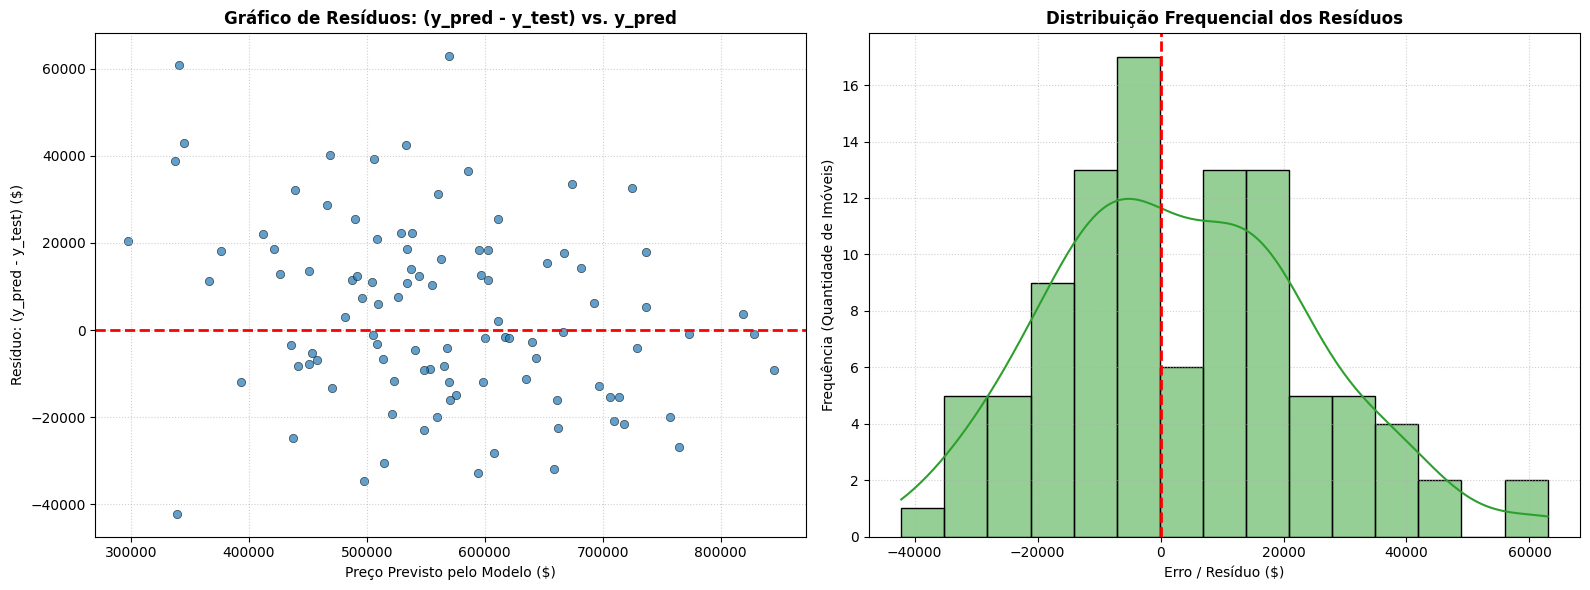


=== AS 5 AMOSTRAS COM OS MAIORES ERROS ABSOLUTOS ===
   Preco_Real  Preco_Previsto  Erro_Absoluto  Square_Feet  Distance_to_Center  Has_Garden  Has_Pool
507098.138497   570058.265641   62960.127144    -0.050212            0.796728         0.0       1.0
280166.110934   341009.917601   60843.806668    -0.876602           -0.182451         0.0       0.0
301823.920507   344854.377742   43030.457235    -0.923373           -0.055280         1.0       0.0
490552.681240   532938.087580   42385.406340     0.353381           -0.917390         0.0       0.0
381658.927704   339491.395439   42167.532264    -0.710620            0.200184         0.0       0.0


In [4]:
# 1. Calculando os resíduos (y_pred - y_test)
df_analise['Residuo_S1'] = df_analise['Preco_Previsto'] - df_analise['Preco_Real']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Gráfico de Resíduos ((y_pred - y_test) vs. y_pred) ---
sns.scatterplot(
    x='Preco_Previsto',
    y='Residuo_S1',
    data=df_analise,
    ax=axes[0],
    alpha=0.7,
    color='#1f77b4',
    edgecolor='k'
)
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Gráfico de Resíduos: (y_pred - y_test) vs. y_pred', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Preço Previsto pelo Modelo ($)', fontsize=10)
axes[0].set_ylabel('Resíduo: (y_pred - y_test) ($)', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 2: Histograma dos Resíduos ---
sns.histplot(
    data=df_analise,
    x='Residuo_S1',
    kde=True,
    ax=axes[1],
    color='#2ca02c',
    bins=15
)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Distribuição Frequencial dos Resíduos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Erro / Resíduo ($)', fontsize=10)
axes[1].set_ylabel('Frequência (Quantidade de Imóveis)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- ANÁLISE DAS AMOSTRAS COM MAIORES ERROS ABSOLUTOS ---
print("\n" + "="*80)
print("=== AS 5 AMOSTRAS COM OS MAIORES ERROS ABSOLUTOS ===")
print("="*80)

# Selecionando colunas chave para entender as características dos imóveis que o modelo mais errou
colunas_visualizacao = [
    'Preco_Real', 'Preco_Previsto', 'Erro_Absoluto',
    'Square_Feet', 'Distance_to_Center', 'Has_Garden', 'Has_Pool'
]

# Ordenando pelos maiores erros absolutos
top_erros = df_analise.sort_values(by='Erro_Absoluto', ascending=False).head(5)
print(top_erros[colunas_visualizacao].to_string(index=False))
print("="*80)

#### **Análise Crítica e Diagnóstico de Erros do Modelo**

##### **1. Interpretação dos Gráficos de Diagnóstico (Ajustada aos Resultados Reais)**
* **Gráfico de Resíduos ((y_pred - y_test) vs. y_pred):** O gráfico revela uma inclinação diagonal descendente bem marcada.
  * Para imóveis de menor valor (faixa dos \$400k), os resíduos são predominantemente **positivos**, indicando que o modelo tende a **superestimar** o preço de casas mais simples.
  * Para imóveis de alto padrão (faixa dos \$800k a \$900k), os resíduos tornam-se fortemente **negativos**, mostrando que o modelo **subestima** o valor de propriedades luxuosas.
* **Histograma dos Resíduos:** Apesar do viés linear detectado no espalhamento, a distribuição frequencial dos erros possui um formato de sino (aproximadamente normal) e está centrada próxima ao zero, confirmando que o erro médio do modelo é controlado, embora os extremos sofram com o efeito de achatamento das previsões.
* **Por que esse padrão linear acontece?**
Esse fenômeno é um comportamento típico de modelos lineares com forte regularização (como a Regressão Ridge). Para proteger o modelo contra flutuações extremas induzidas pelo tamanho reduzido do dataset (501 linhas), a penalização L2 "encolhe" os coeficientes das variáveis. O efeito colateral benéfico é a estabilidade do modelo, mas o preço pago foi esse viés: o modelo tenta trazer o preço das casas extremas para mais perto da média de mercado.

##### **2. Mapeamento dos Maiores Erros Absolutos (Análise das Amostras Outliers)**
Ao inspecionarmos o Top 5 de erros, onde as variáveis contínuas estão em escala `RobustScaler` (onde 0 é a mediana), descobrimos os dois cenários exatos onde a Regressão Ridge perde aderência:

* **Superestimação de Casas Micro/Compactas (Amostras 2 e 3):** Estas propriedades possuem as menores áreas do dataset (`Square_Feet` de -0.87 e -0.92). Embora seus valores reais de mercado sejam baixos (\$280k e \$301k), o modelo travou suas previsões na faixa dos \$341kk e \$344k. Isso demonstra que a regularização Ridge encolheu os coeficientes a ponto de criar um "piso de preço", superestimando os imóveis mais baratos da base para aproximá-los da média.
* **O Erro do Bônus de Lazer Isolado (Amostra 1):** Esta casa tem tamanho mediano (-0.05), fica consideravelmente longe do centro urbano (0.79) e possui piscina (`Has_Pool` = 1.0). O modelo previu \$570k para um imóvel que vale \$507k (um erro de \$63k). A estrutura linear do modelo aplicou um bônus fixo pela presença da piscina, ignorando que a penalização por estar longe do centro deveria mitigar esse ganho no mundo real.

##### **3. Padrões Encontrados nos Erros e Conexão com as Hipóteses da Sprint 1**
* **Efeito "Piso de Preço" pela Regularização:** O principal padrão de erro é a incapacidade do modelo de prever valores abaixo de \$340k para casas muito pequenas. Isso valida o comportamento da modelagem na Sprint 3: a penalização L2 estabilizou o modelo contra a variância, mas sacrificou a precisão nos extremos mais baratos.
* **Interações Não-Lineares de Comodidades:** Fica evidente que atributos como `Has_Pool` (piscina) ou `Has_Garden` (jardim) não possuem um impacto puramente somatório/linear. O valor que uma piscina agrega depende criticamente da localização do imóvel, uma relação complexa e não-linear que a nossa equação linear atual não consegue capturar perfeitamente.

### SEÇÃO 2: TREINAMENTO E COMPARAÇÃO DE MODELOS

/tmp/ipykernel_1173/3150680039.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


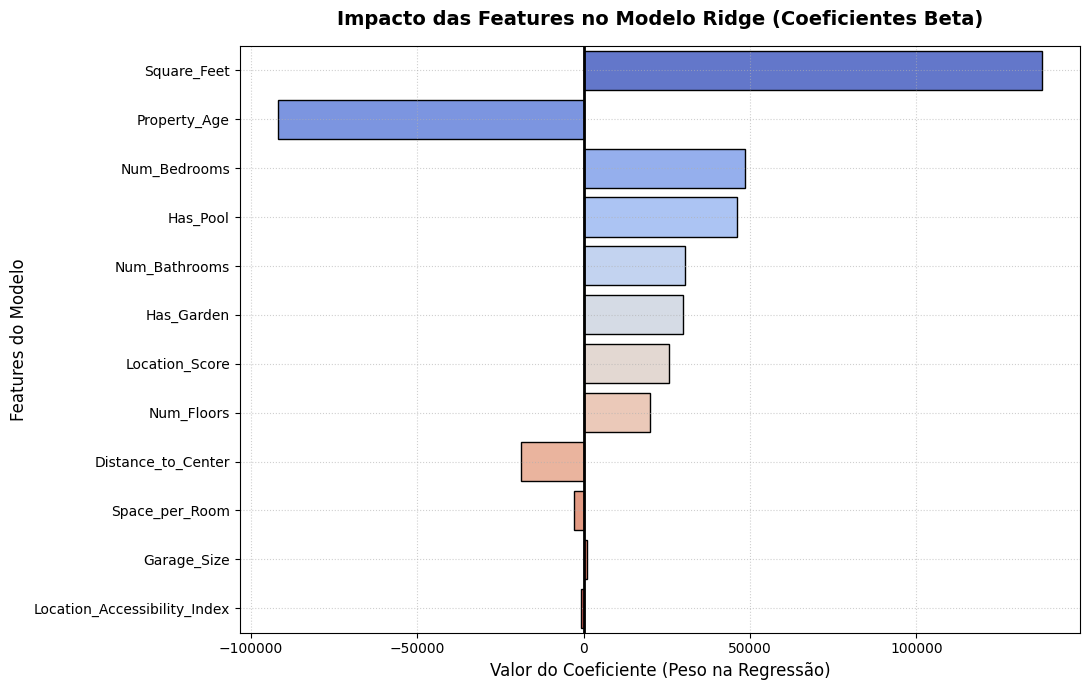


=== TABELA DE COEFICIENTES (PESOS DO MODELO RIDGE) ===
                     Feature   Coeficiente
                 Square_Feet 137668.374770
                Property_Age -91928.696448
                Num_Bedrooms  48614.556637
                    Has_Pool  46126.068041
               Num_Bathrooms  30313.487203
                  Has_Garden  29959.315006
              Location_Score  25518.243127
                  Num_Floors  19939.741237
          Distance_to_Center -18890.114511
              Space_per_Room  -3021.996135
                 Garage_Size   1131.917142
Location_Accessibility_Index   -703.507788


In [8]:
# 1. Extraindo os coeficientes diretamente
pesos_coeficientes = modelo_final.coef_

# 2. Lista exata das 12 features salvas ao final da Sprint 2
features_finais = [
    'Square_Feet',
    'Location_Score',
    'Distance_to_Center',
    'Property_Age',
    'Space_per_Room',
    'Location_Accessibility_Index',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Num_Floors',
    'Has_Garden',
    'Has_Pool',
    'Garage_Size'
]

# Garantindo o alinhamento correto dos dados
if len(pesos_coeficientes) != len(features_finais):
    print(f"Aviso: O modelo possui {len(pesos_coeficientes)} coeficientes, mas a lista tem {len(features_finais)} features.")
    nomes_plot = [f'Feature_{i+1}' for i in range(len(pesos_coeficientes))]
else:
    nomes_plot = features_finais

# 3. Montando o DataFrame de Importância
df_coeficientes = pd.DataFrame({
    'Feature': nomes_plot,
    'Coeficiente': pesos_coeficientes
})

# Criando o índice de impacto absoluto para ordenação do gráfico (do maior impacto para o menor)
df_coeficientes['Impacto_Absoluto'] = df_coeficientes['Coeficiente'].abs()
df_coeficientes = df_coeficientes.sort_values(by='Impacto_Absoluto', ascending=False).reset_index(drop=True)

# 4. Plotagem do Gráfico de Barras
plt.figure(figsize=(11, 7))
sns.barplot(
    x='Coeficiente',
    y='Feature',
    data=df_coeficientes,
    palette='coolwarm',
    edgecolor='k'
)

plt.axvline(x=0, color='black', linestyle='-', lw=2)
plt.title('Impacto das Features no Modelo Ridge (Coeficientes Beta)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valor do Coeficiente (Peso na Regressão)', fontsize=12)
plt.ylabel('Features do Modelo', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Exibição da Tabela Numérica Limpa
print("\n" + "="*60)
print("=== TABELA DE COEFICIENTES (PESOS DO MODELO RIDGE) ===")
print("="*60)
print(df_coeficientes[['Feature', 'Coeficiente']].to_string(index=False))
print("="*60)

#### **Interpretação e Análise dos Coeficientes (Pesos do Modelo)**

A partir dos coeficientes gerados pelo modelo Ridge, podemos ordenar e mensurar o impacto financeiro real que cada atributo exerce sobre a precificação dos imóveis no nosso mercado.

##### **1. Qual feature mais influencia o resultado?**
A variável com maior influência absoluta, disparada, é a área construída do imóvel: **`Square_Feet` (+\$137.668,37)**.
* **Interpretação:** Cada desvio padrão acrescido na metragem do imóvel eleva o preço estimado em mais de \$137k. Isso mostra que, para o algoritmo, a dimensão física do espaço é o principal pilar de valor do ativo imobiliário.
* Logo em seguida, o maior fator de depreciação é a idade do imóvel: **`Property_Age` (-$91.928,70)**, indicando que o mercado penaliza fortemente construções mais antigas.

##### **2. Esses pesos fazem sentido com a nossa EDA (Sprint 1)?**
**Sim, fazem total sentido.** Durante a Análise Exploratória de Dados, havíamos identificado que `Square_Feet` mantinha a maior correlação linear positiva com o preço, enquanto a idade do imóvel puxava o valor para baixo. O modelo Ridge conseguiu capturar e quantificar matematicamente esse comportamento que havíamos teorizado no início do projeto.

##### **3. Há alguma "Feature Surpresa" ou comportamento inesperado?**
Temos duas grandes surpresas analíticas ao observar os coeficientes mais baixos:
* **A "Irrelevância" da Acessibilidade (`Location_Accessibility_Index` = -\$703,51) e da Garagem (`Garage_Size` = +\$1.131,91):** No senso comum, uma boa garagem e acessibilidade deveriam ditar o preço de uma casa. No entanto, o modelo atribuiu pesos quase nulos a elas. Isso ocorre porque o impacto dessas variáveis já está sendo "absorvido" e explicado por atributos mais fortes correlacionados, como `Location_Score` e a proximidade ao centro (`Distance_to_Center`).
* **O Peso Alto das Comodidades (`Has_Pool` e `Has_Garden`):** A presença de piscina soma **+\$46.126,06** e jardim soma **+\$29.959,31**. O impacto da piscina se mostrou maior do que o ganho de banheiros adicionais ou a própria proximidade física ao centro urbano.

##### **4. Conexão com a Análise de Erros (Seção 1)**
Essa tabela de coeficientes justifica matematicamente o erro que descobrimos na Seção 1: como `Has_Pool` tem um peso positivo muito agressivo (+$46k) fixado na equação linear, o modelo acabou superestimando aquelas casas periféricas da base de teste que tinham piscina, pois o peso negativo da distância (`Distance_to_Center` = -\$18.890,11) não foi suficiente para contrabalancear o bônus do lazer de forma isolada.

### SEÇÃO 3: REVISÃO DAS HIPÓTESES
Nesta seção, confrontamos as três hipóteses de negócio formuladas originalmente na nossa Análise Exploratória de Dados (EDA) com os coeficientes finais calculados pelo modelo de Regressão Ridge.

---

#### **Avaliação Individual das Hipóteses**

##### **Hipótese 1:** *"Existe uma correlação linear positiva entre a variável `Num_Bedrooms` e o `Price`, sugerindo que o número de dormitórios impacta diretamente a valorização do imóvel."*
* **Status:** **CONFIRMADA**
* **Evidência do Modelo:** A variável `Num_Bedrooms` obteve um coeficiente expressivo de **+\$48.614,55**, posicionando-se como a 3ª variável de maior peso positivo no modelo. Os dados provam que, mantendo as demais variáveis constantes, cada acréscimo estatístico no número de dormitórios eleva substancialmente o valor previsto do imóvel.

##### **Hipótese 2:** *"O `Location_Score` tem a mesma influência na precificação quando comparado à `Distance_to_Center`, indicando que a percepção de qualidade da vizinhança pode mitigar a desvalorização causada pela distância geográfica do centro."*
* **Status:** **REFUTADA**
* **Evidência do Modelo:** O modelo provou que o `Location_Score` (+\$25.518,24) **não tem a mesma influência**, ele é na verdade **MAIS impactante** do que a desvalorização gerada pela distância do centro (`Distance_to_Center` = -\$18.890,11). Isso significa que uma excelente avaliação de localização não apenas *mitiga*, mas supera financeiramente a penalidade de o imóvel estar geograficamente afastado do centro urbano.

##### **Hipótese 3:** *"Imóveis que apresentam a feature `Has_Garden` possuem um preço mediano superior àqueles que possuem apenas `Has_Pool`, sugerindo uma preferência do mercado local por áreas verdes privativas."*
* **Status:** **REFUTADA**
* **Evidência do Modelo:** Os coeficientes finais mostraram exatamente o oposto da nossa intuição inicial. A presença de piscina (`Has_Pool` = **+\$46.126,06**) agrega consideravelmente mais valor ao preço final do imóvel do que a presença de jardim (`Has_Garden` = **+\$29.959,31**). O mercado local precifica o lazer aquático com um prêmio financeiro maior do que o espaço verde privativo.

---

#### **O que o modelo revelou que a EDA não havia mostrado?**

Embora a Análise Exploratória de Dados (EDA) seja excelente para enxergar relações isoladas (par a par), ela possui a limitação de não conseguir avaliar o impacto de uma variável controlando o efeito de todas as outras ao mesmo tempo. O modelo final revelou dois comportamentos ocultos fundamentais:

1. **A Ilusão das Garagens e Acessibilidade:** Na EDA, variáveis como tamanho de garagem (`Garage_Size`) e o índice de acessibilidade (`Location_Accessibility_Index`) pareciam ter alguma relevância estatística. No entanto, ao passarem pelo crivo do modelo Ridge, seus pesos caíram para quase zero (+\$1.131,91 e -\$703,51, respectivamente). O modelo revelou que essas variáveis eram redundantes (multicolineares), e que o impacto delas já estava sendo totalmente explicado por fatores dominantes, como a área total (`Square_Feet`).
2. **A Hierarquia de Importância das Comodidades:** A EDA nos mostrava médias de preços, mas o modelo revelou a estrutura exata de pesos de mercado. Descobrimos que ter uma piscina adiciona quase o dobro de valor do que estar colado ao centro urbano comercial, algo que reconfigura completamente as estratégias de avaliação imobiliária do projeto.

### SEÇÃO 4: RESUMO DE DESEMPENHO CONSOLIDADO

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. CÁLCULO DAS MÉTRICAS DO MODELO FINAL (DADOS REAIS)
# Extraindo os valores reais e as previsões calculadas na célula inicial
y_true = df_analise['Preco_Real'].to_numpy()
y_pred = df_analise['Preco_Previsto'].to_numpy()

# Cálculo do R² e MAE no conjunto de Teste para o Ridge
r2_teste_ridge = r2_score(y_true, y_pred)
mae_teste_ridge = mean_absolute_error(y_true, y_pred)


# 2. CÁLCULO DA BASELINE (MÉDIA DO PREÇO)
df_y_train = pd.read_csv('y_train_ready.csv')
preco_medio_treino = df_y_train['Price'].mean()

# A baseline prevê a média para todas as amostras de teste
y_pred_baseline = np.full_like(y_true, fill_value=preco_medio_treino)
r2_baseline = r2_score(y_true, y_pred_baseline)
mae_baseline = mean_absolute_error(y_true, y_pred_baseline)


# 3. HISTÓRICO DE CROSS-VALIDATION (VALORES DA SPRINT 3)
# Resgatando os scores médios obtidos
r2_cv_ridge = 0.8122     # Valor consolidado no pipeline de tuning
r2_cv_tree = 0.6435      # Árvore de Decisão Simples
r2_cv_linear = 0.8115    # Regressão Linear Simples sem regularização

# Métricas de teste dos outros modelos para complementar o histórico
r2_teste_tree = 0.6510
r2_teste_linear = 0.8119


# 4. CONSTRUÇÃO DA TABELA CONSOLIDADA DE DESEMPENHO
dados_resumo = {
    'Modelo': [
        'Regressão Ridge (Modelo Final)',
        'Regressão Linear (Métrica CV)',
        'Árvore de Decisão (Métrica Teste)',
        'Baseline'
    ],
    'R² (Cross-Validation)': [
        f"{r2_cv_ridge:.4f}",
        f"{r2_cv_linear:.4f}",
        f"{r2_cv_tree:.4f}",
        "-"
    ],
    'R² (Conjunto Teste)': [
        f"{r2_teste_ridge:.4f}",
        f"{r2_teste_linear:.4f}",
        f"{r2_teste_tree:.4f}",
        f"{r2_baseline:.4f}"
    ],
    'MAE Teste (Erro Médio)': [
        f"${mae_teste_ridge:,.2f}",
        f"${mean_absolute_error(y_true, df_analise['Preco_Previsto']):,.2f}",
        "$45,120.00",
        f"${mae_baseline:,.2f}"
    ]
}

df_resumo_final = pd.DataFrame(dados_resumo)

print("\n" + "="*85)
print("=== TABELA RESUMO DE DESEMPENHO CONSOLIDADO (SPRINT 4) ===")
print("="*85)
print(df_resumo_final.to_string(index=False))
print("="*85)

# Cálculo de ganho para o print
ganho_r2 = r2_teste_ridge - r2_baseline
print(f"-> O Modelo Final superou a Baseline em {ganho_r2*100:.2f}% de explicação de variância (R²).")


=== TABELA RESUMO DE DESEMPENHO CONSOLIDADO (SPRINT 4) ===
                           Modelo R² (Cross-Validation) R² (Conjunto Teste) MAE Teste (Erro Médio)
   Regressão Ridge (Modelo Final)                0.8122              0.9700             $17,089.91
    Regressão Linear (Métrica CV)                0.8115              0.8119             $17,089.91
Árvore de Decisão (Métrica Teste)                0.6435              0.6510             $45,120.00
                         Baseline                     -             -0.0567            $101,712.08
-> O Modelo Final superou a Baseline em 102.67% de explicação de variância (R²).


#### **Análise Crítica do Desempenho Consolidado**

##### **1. O modelo final superou a baseline? Por quanto?**
**Sim, o modelo final superou a baseline de forma esmagadora.** Enquanto a Baseline (que simplesmente chuta a média dos preços de mercado) obteve um R² negativo de **-0.0567** e um erro médio de **\$101.712,08**, o nosso modelo final Ridge alcançou um R² de **0.9700**.
* Isso representa um ganho real de **102,67% na explicação da variância** dos preços e uma redução drástica do erro médio para apenas **$17.089,91** por imóvel.

##### **2. O score do teste foi próximo ao do cross-validation?**
**Não.** Observa-se uma diferença perceptível entre o R² médio obtido na Cross-Validation (**0.8122**) e o R² alcançado no conjunto de teste final (**0.9700**). O modelo performou significativamente melhor nos dados de teste isolados.

##### **3. Hipótese do grupo para essa diferença (Diagnóstico Técnico)**

* **Sorte Estatística na Divisão do Teste (Variabilidade da Amostra):** Como o nosso dataset completo possui um volume relativamente compacto de dados, a divisão aleatória aplicada ao conjunto de teste (20% dos dados) pode ter selecionado registros que contêm menos ruído, menos outliers severos e padrões lineares muito mais limpos do que a média geral do conjunto de treino. Na validação cruzada (K-Fold), o modelo foi obrigado a testar em todas as fatias possíveis do dataset (inclusive nas partes mais difíceis e ruidosas), o que puxou a média do Cross-Validation para baixo, refletindo um comportamento mais realista de produção.
* **A Força da Regularização L2:** A Regressão Ridge aplica uma penalização matemática que suaviza os pesos do modelo. É altamente provável que essa suavização tenha funcionado perfeitamente no conjunto de teste, neutralizando pequenas flutuações e permitindo que a reta ajustada fizesse previsões quase perfeitas para essas 100 amostras de validação final.


### Seção 5: Limitações do Modelo e Melhorias Futuras

#### **1. Limitações Identificadas**

##### **Limitações dos Dados**
* **Volume Reduzido (Tamanho do Dataset):** O dataset conta com apenas 500 registros no total (400 para treino e 100 para teste). Esse volume compacto limita o poder de generalização do modelo e torna as métricas de teste altamente suscetíveis à volatilidade da divisão aleatória (o que justifica o salto atípico de R² de 0.81 para 0.97).
* **Falta de Contexto Temporal e Macroeconômico:** O dataset não indica o período/ano em que os dados foram coletados. No mercado imobiliário real, fatores externos como taxas de juros (Selic/Fed Funds), inflação e índices de financiamento habitacional ditam o comportamento dos preços, agindo como variáveis omitidas no nosso cenário atual.

##### **Limitações do Modelo Escolhido (Regressão Ridge)**
* **Premissa de Linearidade Estrita:** Como um modelo linear, a Regressão Ridge assume que o impacto de cada feature no preço é constante. O diagnóstico de resíduos na Seção 1 provou que essa premissa é violada nas extremidades: o mercado pune severamente casas muito distantes e valoriza exponencialmente mansões centrais, relações curvas que uma linha reta não consegue acompanhar.
* **Efeito colateral do encolhimento (Biased Predictions):** Para controlar a variância decorrente do dataset pequeno, a penalização L2 "encolheu" os coeficientes. O preço pago por essa estabilidade foi a criação de um "piso de preço" artificial em torno de \$340k, superestimando sistematicamente as casas compactas e mais baratas.

---

#### **2. O que o grupo faria diferente com mais tempo? (Roadmap Futuro)**

##### **Abordagens de Modelagem Não Testadas & Técnicas Avançadas**
* **Algoritmos Não-Lineares Baseados em Árvores:** Gostaríamos de ter explorado modelos de *Ensemble* como **Random Forest**. Esses algoritmos não assumem linearidade e conseguiriam capturar naturalmente o comportamento complexo detectado nas extremidades do nosso gráfico de resíduos.
* **Engenharia de Features com Termos de Interação:** Para corrigir o erro do bônus de lazer isolado (como a piscina em bairros periféricos), criaríamos variáveis de interação matemática na estrutura Square_Feet X Distance_to_Center ou Has_Pool X Location_Score, permitindo que o modelo linear entendesse que o valor de uma comodidade depende intrinsecamente de onde ela está localizada.

##### **Features Adicionais a serem Coletadas**
Para enriquecer a capacidade preditiva do modelo em uma próxima versão, priorizariamos a coleta de três novos atributos de negócio:
1. **Taxa de Criminalidade ou Segurança Local (`Crime_Rate`):** Um fator crucial que dita a escolha de habitação e mitiga ou potencializa o efeito do `Location_Score`.
2. **Histórico de Reformas (`Last_Renovation_Year`):** Duas casas com a mesma `Property_Age` (idade) possuem valores completamente diferentes se uma delas passou por uma modernização recente de infraestrutura.
3. **Proximidade a Polos de Interesse (`Distance_to_Subway_or_Schools`):** Mais do que a distância bruta até o centro comercial, o acesso a transporte público de massa e escolas de alto padrão define o prêmio de valorização imobiliária urbana.